In [4]:
import torch
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

X = housing['data']
y = housing['target']

X_train_full, X_test, y_train_full, y_test = train_test_split(X,y)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full,y_train_full)

print(X_train.shape, X_test.shape, X_valid.shape)

scl = StandardScaler()
scl.fit(X_train)

X_train = scl.transform(X_train)
X_test = scl.transform(X_test)
X_valid = scl.transform(X_valid)

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
X_valid = torch.FloatTensor(X_valid)

y_train = torch.FloatTensor(y_train).view(-1,1)
y_test = torch.FloatTensor(y_test).view(-1,1)
y_valid = torch.FloatTensor(y_valid).view(-1,1)

# y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
# y_test = torch.tensor(y_test, dtype=torch.float32).view(-1,1)
# y_valid = torch.tensor(y_valid, dtype=torch.float32).view(-1,1)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
valid_dataset = TensorDataset(X_valid, y_valid)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)
valid_loader = DataLoader(valid_dataset, batch_size=32)

(11610, 8) (5160, 8) (3870, 8)


In [6]:
import torch.nn as nn
import torchmetrics
import matplotlib.pyplot as plt
import numpy as np

In [7]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cpu'

In [32]:
def train_one_epoch(
	model, 
	metric, 
	criterion,
	optimizer,
	train_loader,
	clip_grad
):
	total_loss = 0
	metric.reset()

	for X_batch, y_batch in train_loader:
		X_batch, y_batch = X_batch.to(device), y_batch.to(device)
		model.train()
		y_pred = model(X_batch)
		loss = criterion(y_pred, y_batch)
		total_loss += loss.item()
		loss.backward()
		if clip_grad:
			nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
		optimizer.step()
		# for group in optimizer.param_groups:
		# 	for p in group['params']:
		# 		if p.grad is not None:
		# 			print(f'\t{p.grad.max()}') 
		optimizer.zero_grad()
		metric.update(y_pred, y_batch)
	
	avg_loss = total_loss / len(train_loader)
	avg_metric_train = metric.compute().item()

	return avg_loss, avg_metric_train

def evaluate_one_epoch(model, metric, valid_loader):
	model.eval()
	metric.reset()
	with torch.no_grad():
		for X_batch, y_batch in valid_loader:
			X_batch, y_batch = X_batch.to(device), y_batch.to(device)
			y_pred = model(X_batch)
			metric.update(y_pred, y_batch)

	avg_metric_valid = metric.compute().item()
	return avg_metric_valid

def schedule_lr(epoch, optimizer, valid_metric, scheduler, warmup_scheduler):
	if scheduler is not None:
		# need_to_step:bool = (epoch >= warmup_scheduler.total_iters) if warmup_scheduler is not None else True
		need_to_step:bool = epoch >= (warmup_scheduler.total_iters if warmup_scheduler is not None else 0)
		if need_to_step:
			if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
				scheduler.step(valid_metric)
			else:
				scheduler.step()

	learning_rate = optimizer.param_groups[0]['lr']
	return learning_rate

In [60]:
def train(
	model, 
	optimizer, 
	criterion, 
	metric, 
	train_loader, 
	valid_loader, 
	n_epochs,
	warmup_scheduler=None,
	scheduler=None,
	patience=None,
	checkpoint_path="best_model.pt",
	clip_grad=False
	):
	history = {
		'loss' : [],
		'train_metric' : [],
		'valid_metric' : [],
		'learning_rate' : [],
	}
	best_epoch = 0
	best_valid_metric = (
		float('-inf') if metric.higher_is_better else 
		float('inf')
	)
	patience_counter=0

	for epoch in range(n_epochs):
		#----------------------------------------------------------------
		# Warmup scheduling
		#----------------------------------------------------------------
		if warmup_scheduler is not None:
			warmup_scheduler.step()

		#----------------------------------------------------------------
		# Training 
		#----------------------------------------------------------------
		train_loss, train_metric = train_one_epoch(model, metric, criterion,optimizer,train_loader,clip_grad)

		#----------------------------------------------------------------
		# Evaluation 
		#----------------------------------------------------------------
		valid_metric = evaluate_one_epoch(model, metric, valid_loader)

		#----------------------------------------------------------------
		# Checkpoint
		#----------------------------------------------------------------
		
		is_best_result = (
			valid_metric > best_valid_metric if metric.higher_is_better else 
			valid_metric < best_valid_metric
		)
		if is_best_result:
			torch.save(model.state_dict(), checkpoint_path)
			best_epoch = epoch + 1
			best_valid_metric = valid_metric

		#----------------------------------------------------------------
		# Scheduling
		#----------------------------------------------------------------
		learning_rate = schedule_lr(epoch, optimizer, valid_metric, scheduler, warmup_scheduler)

		#----------------------------------------------------------------
		# Logging
		#----------------------------------------------------------------
		history['loss'].append(train_loss)
		history['train_metric'].append(train_metric)
		history['valid_metric'].append(valid_metric)
		history['learning_rate'].append(learning_rate)

		print(
			f'Epoch: {epoch+1}/{n_epochs}, '
			+f'Loss: {round(train_loss,3)}, '
			+f'Train Metric: {round(train_metric,3)}, ' 
			+f'Valid Metric: {round(valid_metric,3)}, '
			+f'LR: {round(learning_rate, 3)}'
		)

		if is_best_result:
			print(f'\tCheckpoint, valid_metric:{round(valid_metric,3)}')

		#----------------------------------------------------------------
		# Early stopping
		#----------------------------------------------------------------
		if patience is not None:
			if is_best_result:
				patience_counter = 0
			else:
				patience_counter += 1
				if patience_counter >= patience:
					break
	
		model.load_state_dict(torch.load(checkpoint_path))
	return history

def plot_history(history, metric):
	n_epochs = len(history['loss'])

	fig, axs = plt.subplots(1, 2, figsize=(12,4))

	axs[0].plot(np.arange(n_epochs) + 1, history['train_metric'], linestyle='--', color='r', marker='.', label='Train')
	axs[0].plot(np.arange(n_epochs) + 1, history['valid_metric'], linestyle='--', color='b', marker='.', label='Valid')
	axs[0].legend()
	axs[0].grid()
	axs[0].set_xlabel('Epochs')
	axs[0].set_ylabel(f'{metric.__class__.__name__}')

	axs[1].plot(np.arange(n_epochs) + 1, history['learning_rate'], linestyle='--', color='r', marker='.', label='Train')
	axs[1].legend()
	axs[1].grid()
	axs[1].set_xlabel('Epochs')
	axs[1].set_ylabel('Learning Rate')

	plt.show()

In [56]:
learning_rate = 0.1
n_epochs=30

model = nn.Sequential(
	nn.Linear(in_features=8, out_features=30), 
	nn.LeakyReLU(),
	nn.Linear(in_features=30, out_features=50), 
	nn.LeakyReLU(),
	nn.Linear(in_features=50, out_features=1),
).to(device)

def use_he_init(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_uniform_(module.weight, nonlinearity='leaky_relu')
        nn.init.zeros_(module.bias)
model.apply(use_he_init)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=3)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = train(
    model, 
	optimizer, 
	criterion, 
	metric, 
	train_loader, 
	valid_loader, 
	n_epochs, 
	warmup_scheduler,
	scheduler,
	patience=3,
	clip_grad=True
	)

C:\Users\user\AppData\Local\Temp\ipykernel_4920\995083352.py:33: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warmup_scheduler.step()


Epoch: 1/30, Loss: 0.857, Train Metric: 0.634, Valid Metric: 0.495, LR: 0.04
	Checkpoint, valid_metric:0.495
Epoch: 2/30, Loss: 0.621, Train Metric: 0.521, Valid Metric: 0.458, LR: 0.07
	Checkpoint, valid_metric:0.458
Epoch: 3/30, Loss: 0.576, Train Metric: 0.512, Valid Metric: 0.437, LR: 0.1
	Checkpoint, valid_metric:0.437
Epoch: 4/30, Loss: 0.508, Train Metric: 0.485, Valid Metric: 0.451, LR: 0.09
Epoch: 5/30, Loss: 0.467, Train Metric: 0.482, Valid Metric: 0.502, LR: 0.081
Epoch: 6/30, Loss: 0.469, Train Metric: 0.476, Valid Metric: 0.431, LR: 0.073
	Checkpoint, valid_metric:0.431
Epoch: 7/30, Loss: 0.431, Train Metric: 0.46, Valid Metric: 0.43, LR: 0.066
	Checkpoint, valid_metric:0.43
Epoch: 8/30, Loss: 0.432, Train Metric: 0.448, Valid Metric: 0.433, LR: 0.059
Epoch: 9/30, Loss: 0.399, Train Metric: 0.443, Valid Metric: 0.429, LR: 0.053
	Checkpoint, valid_metric:0.429
Epoch: 10/30, Loss: 0.384, Train Metric: 0.437, Valid Metric: 0.41, LR: 0.048
	Checkpoint, valid_metric:0.41
Epoch

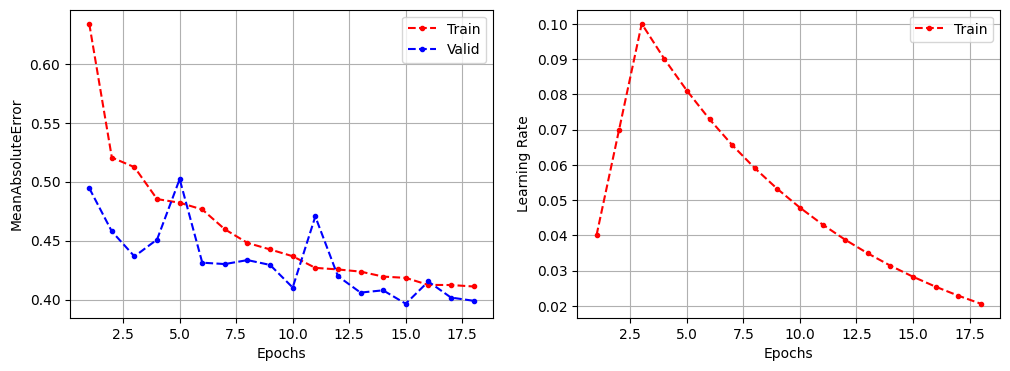

In [61]:
plot_history(history, metric)

In [62]:
from custom_utils import train, plot_history